# Images EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from tqdm import tqdm
import random
import warnings

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Load paths from .env file
data_dir = os.getenv("DATA_DIR")
images_dir = os.getenv("IMAGES_DIR")

# Load the unified TSV file
annotations_file = os.path.join(data_dir, "annotations.tsv")

In [4]:
df = pd.read_csv(annotations_file, sep="\t")

In [5]:
print(os.listdir(images_dir))

['california_wildfires', 'hurricane_harvey', 'hurricane_irma', 'hurricane_maria', 'iraq_iran_earthquake', 'mexico_earthquake', 'srilanka_floods']


In [6]:
print(os.listdir(images_dir + "/california_wildfires"))

['10_10_2017', '11_10_2017', '12_10_2017', '15_10_2017', '16_10_2017', '17_10_2017', '18_10_2017', '19_10_2017', '20_10_2017', '21_10_2017', '22_10_2017', '23_10_2017', '24_10_2017', '25_10_2017', '26_10_2017', '27_10_2017']


In [7]:
print(os.listdir(images_dir + "/california_wildfires/10_10_2017"))

['._917791044158185473_0.jpg', '._917793736918216706_0.jpg', '._917821459321556992_0.jpg', '._917825152636907523_0.jpg', '._917827226372132864_0.jpg', '._917830092620836864_0.jpg', '._917851921943318528_0.jpg', '917791044158185473_0.jpg', '917791130590183424_0.jpg', '917791291823591425_0.jpg', '917791291823591425_1.jpg', '917792092100988929_0.jpg', '917792147700465664_0.jpg', '917792930315821057_0.jpg', '917793137925459968_0.jpg', '917793137925459968_1.jpg', '917793137925459968_2.jpg', '917793158251077632_0.jpg', '917793736918216706_0.jpg', '917793881533571073_0.jpg', '917794024173563904_0.jpg', '917794232160661505_0.jpg', '917794360581869569_0.jpg', '917794580728295424_0.jpg', '917794892113498113_0.jpg', '917795098523512962_0.jpg', '917795236595863552_0.jpg', '917796280377602048_0.jpg', '917796307191951360_0.jpg', '917796883610820608_0.jpg', '917796940900982786_0.jpg', '917797601763889160_0.jpg', '917797763282214913_0.jpg', '917800657796595715_0.jpg', '917803185317859329_0.jpg', '9178

Image Label Task 1: informative
Image Label Confidence: 1.0

Image Label Task 2: infrastructure_and_utility_damage
Image Label Confidence: 1.0

Image Label Task 3: severe_damage
Image Label Confidence: 0.6549


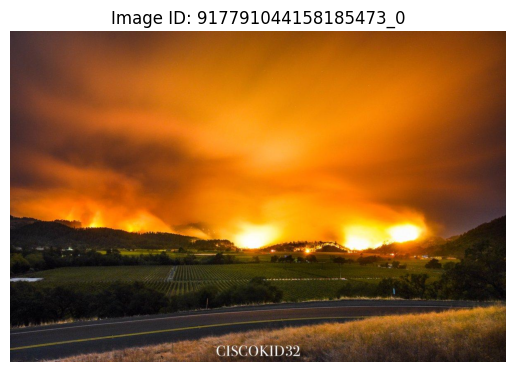

In [8]:
random_row = df.iloc[100]
image_path = random_row["image_path"]

# Open and display the image
image = Image.open("../" + image_path)

print(f'Image Label Task 1: {random_row["image_info"]}')
print(f'Image Label Confidence: {random_row["image_info_conf"]}')
print(f'\nImage Label Task 2: {random_row["image_human"]}')
print(f'Image Label Confidence: {random_row["image_human_conf"]}')
print(f'\nImage Label Task 3: {random_row["image_damage"]}')
print(f'Image Label Confidence: {random_row["image_damage_conf"]}')

plt.imshow(image)
plt.axis('off')
plt.title(f"Image ID: {df.iloc[0]['image_id']}")
plt.show()


## Distribuzione della shape delle immagini

In [9]:
# Inizializza le liste
widths = []
heights = []
aspect_ratios = []
missing = []

# iteration on each image
for idx, row in tqdm(df.iterrows(), total=len(df)):
    image_path = row["image_path"]

    try:
        with Image.open("../" + image_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
    except Exception as e:
        #for missing images
        missing.append(row["image_path"])
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)

#Added to the dataframe
df["img_width"] = widths
df["img_height"] = heights
df["img_aspect_ratio"] = aspect_ratios


100%|██████████| 18082/18082 [00:31<00:00, 569.95it/s]


In [10]:
print(f"Missing images: {len(missing)}")

print(f'{len(df["img_width"].unique())} Different width values')
print(f'{len(df["img_height"].unique())} Different height values')
print(f'{len(df["img_aspect_ratio"].unique())} Different aspect ratio values')


Missing images: 0
949 Different width values
1037 Different height values
4728 Different aspect ratio values


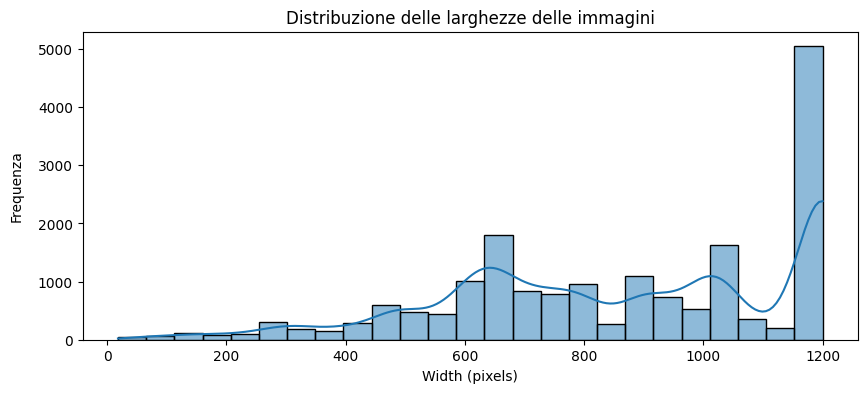

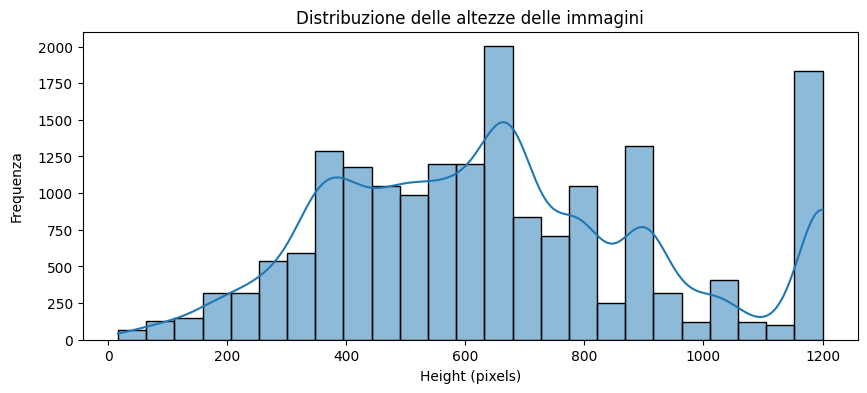

In [11]:
# Istogramma della larghezza
plt.figure(figsize=(10, 4))
sns.histplot(df['img_width'], bins=25, kde=True)
plt.title('Distribuzione delle larghezze delle immagini')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequenza', labelpad=10)
plt.show()

# Istogramma dell'altezza
plt.figure(figsize=(10, 4))
sns.histplot(df['img_height'], bins=25, kde=True)
plt.title('Distribuzione delle altezze delle immagini')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequenza', labelpad=10)
plt.show()


## Relazione tra Tweet e Immagini

In [84]:
n_tweets = len(df["tweet_id"].unique())
n_image = len(df["image_path"].unique())

top_tweets = (
    df.groupby("tweet_id")["image_path"]
    .count()
    .sort_values(ascending=False)
)

# Filtra quelli con più di 1 immagine
top_tweets = top_tweets[top_tweets > 1]

print(f"{str(n_tweets)} total tweets")
print(f"{str(n_image)} total images")
print(f"{len(top_tweets)} tweet hanno più di un immagine associata")
top_tweets


16058 total tweets
18082 total images
1145 tweet hanno più di un immagine associata


tweet_id
931493766816559104    4
869972354004393987    4
904221556938825729    4
904581253629804544    4
930058600160088065    4
                     ..
871734745394102272    2
914701520066813952    2
904623406133501953    2
904572280981790720    2
904528383903621121    2
Name: image_path, Length: 1145, dtype: int64

## Funzioni di plotting

In [72]:
sns.set(style="whitegrid")  # stile seaborn
warnings.filterwarnings("ignore", category=FutureWarning)

# Funzione 1: Barplot migliorato
def plot_label_distribution(df, label_col, title=None):
    label_counts = df[label_col].value_counts()
    n_labels = len(label_counts)

    plt.figure(figsize=(7, 5) if n_labels == 2 else (10, 6))
    width = 0.5 if n_labels == 2 else 0.8
    ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis", width=width)

    plt.title(title or f"Label Distribution: {label_col}", fontsize=16, fontweight='bold')
    plt.xlabel(label_col.replace("_", " ").title(), fontsize=12, fontweight='bold')
    plt.ylabel("Number of Images", fontsize=12, labelpad=20, fontweight='bold')

    if n_labels > 2:
         plt.xticks(rotation=30, ha='right', fontsize=10)
    else:
         plt.xticks(rotation=0, fontsize=10)
    
    for i, count in enumerate(label_counts.values):
        ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.show()


# Funzione 2: Griglia immagini migliorata per ogni label
def show_one_image_per_label(df, label_col, image_root="data_image", random_seed=42, resize_to=(224, 224)):
    unique_labels = sorted(df[label_col].dropna().unique())
    random.seed(random_seed)

    n_labels = len(unique_labels)
    fig, axes = plt.subplots(1, n_labels, figsize=(n_labels * 3, 3), constrained_layout=True)
    fig.suptitle(f"One Sample per Class – {label_col.replace('_', ' ').title()}", fontsize=14, fontweight='bold')

    for i, label in enumerate(unique_labels):
        ax = axes[i] if n_labels > 1 else axes
        ax.axis('off')

        sample_row = df[df[label_col] == label].sample(1, random_state=random_seed).iloc[0]
        image_path = "../" + sample_row["image_path"]

        try:
            img = Image.open(image_path).resize(resize_to)
            ax.imshow(img)
            ax.set_title(f"{label}", fontsize=10)
        except Exception as e:
            ax.set_title("Error", fontsize=9)
            print(f"Error loading image {image_path}: {e}")

    plt.show()


def plot_confidence_boxplot(df, label_col, conf_col, title=None):
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, y=label_col, x=conf_col, palette="Set2")

    plt.title("Confidence per Humanitarian Category", fontsize=14, fontweight="bold")
    plt.xlabel("Confidence Score", fontsize=12, fontweight="bold", labelpad=10)
    plt.ylabel("Image Human Label", fontsize=12, fontweight="bold")
    plt.xlim(0, 1.05)
    plt.tight_layout()
    plt.show()




## Task 1 - Informative vs Non Informative

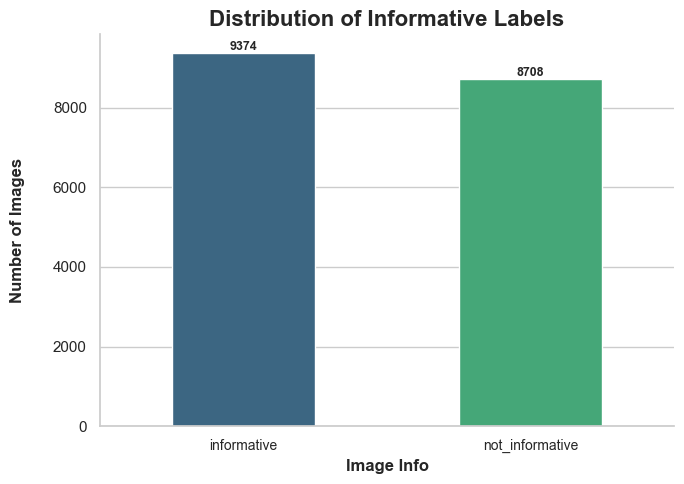

In [70]:
plot_label_distribution(df, "image_info", "Distribution of Informative Labels")

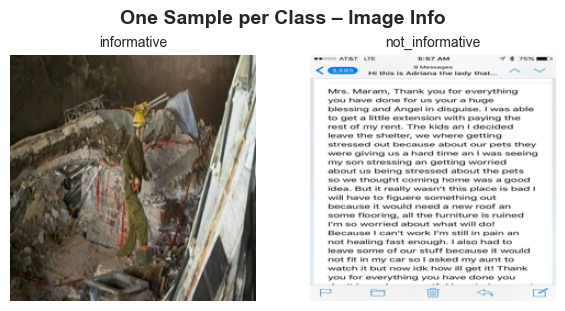

In [14]:
show_one_image_per_label(df, "image_info")

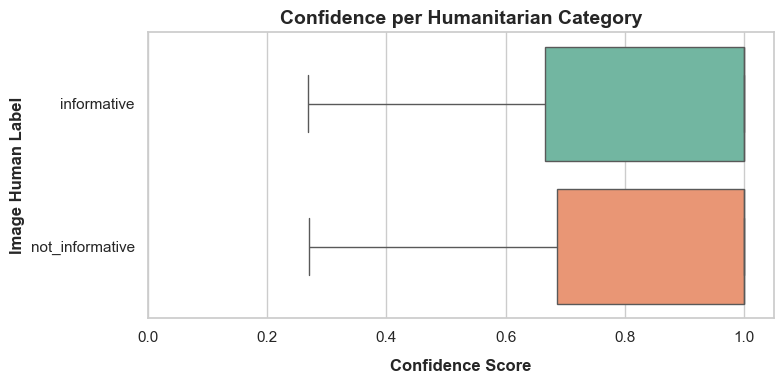

In [56]:
plot_confidence_boxplot(df, "image_info", "image_info_conf", "Confidence per Image Info Label")

## Task 2 - Humanitarian categories

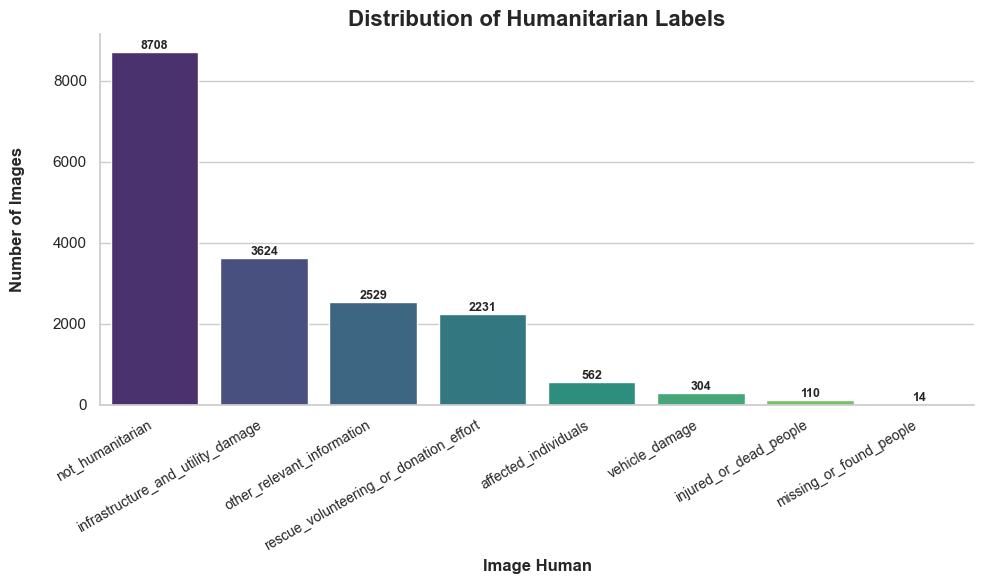

In [73]:
plot_label_distribution(df, "image_human", "Distribution of Humanitarian Labels")

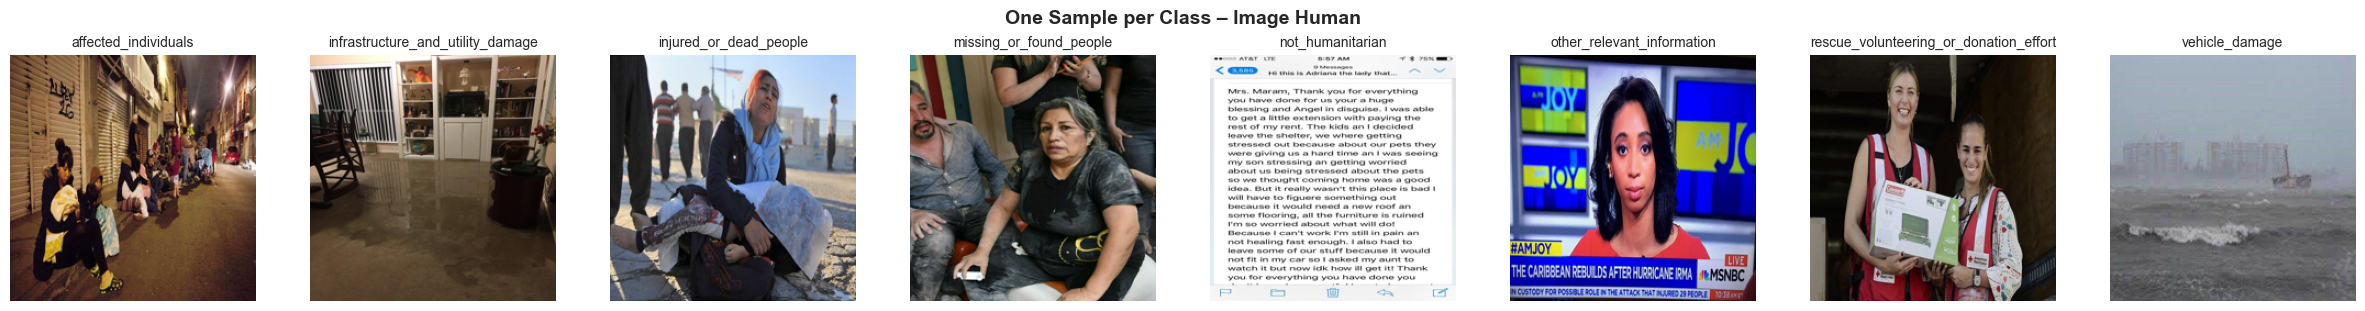

In [21]:
show_one_image_per_label(df, "image_human")

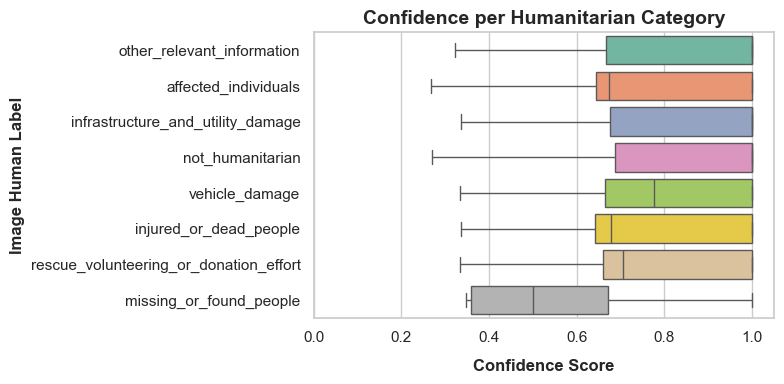

In [57]:
plot_confidence_boxplot(df, "image_human", "image_human_conf", "Confidence per Humanitarian Category")

## Task 3 - Damage severity assessment

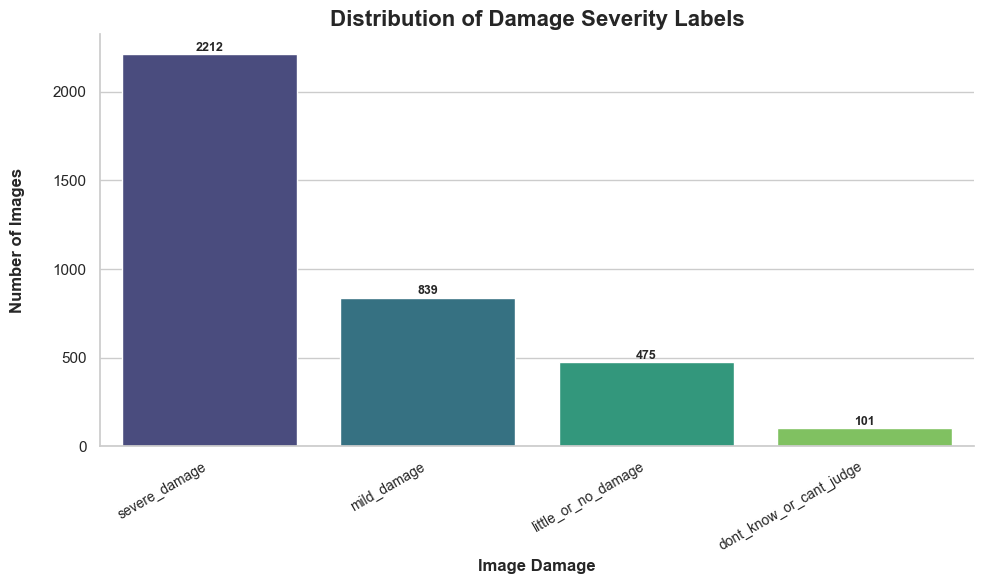

In [74]:
plot_label_distribution(df, "image_damage", "Distribution of Damage Severity Labels")

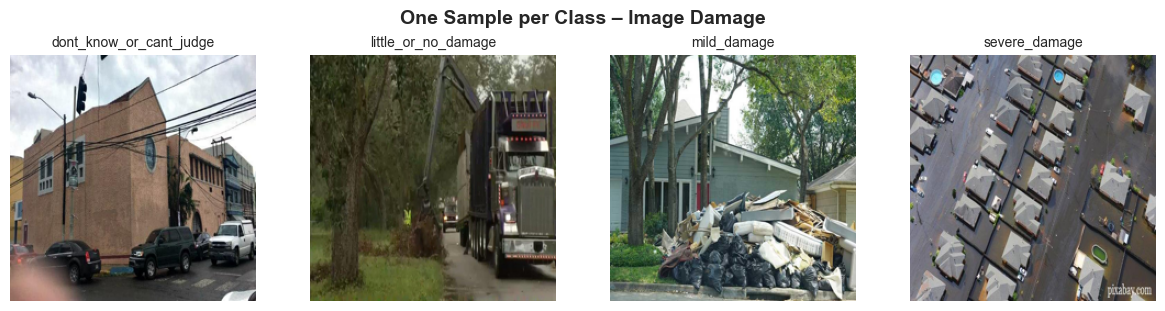

In [24]:
show_one_image_per_label(df, "image_damage")

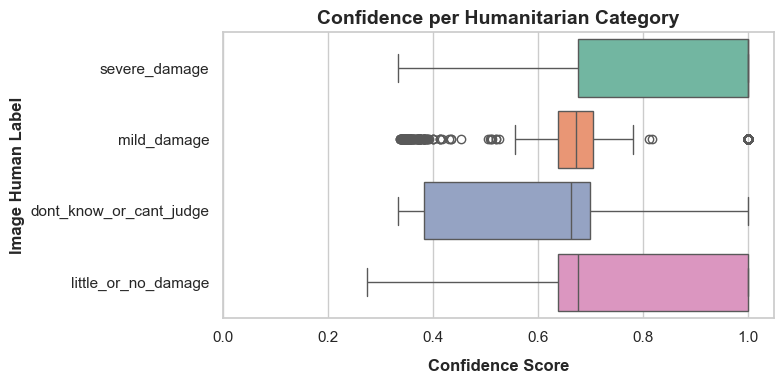

In [59]:
plot_confidence_boxplot(df, "image_damage", "image_damage_conf", "Confidence per Image Info Label")